In [1]:
import os
import gc
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

DATA_DIR = "/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml"

TRANS_FILE = os.path.join(DATA_DIR, "LI-Small_Trans.csv")
ACCOUNTS_FILE = os.path.join(DATA_DIR, "LI-Small_accounts.csv")
PATTERNS_FILE = os.path.join(DATA_DIR, "LI-Small_Patterns.txt")

print("Trans exists:", os.path.exists(TRANS_FILE))
print("Accounts exists:", os.path.exists(ACCOUNTS_FILE))
print("Patterns exists:", os.path.exists(PATTERNS_FILE))

Trans exists: True
Accounts exists: True
Patterns exists: True


In [2]:
usecols = [
    "Timestamp",
    "From Bank",
    "Account",
    "To Bank",
    "Account.1",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering"
]

df = pd.read_csv(
    TRANS_FILE,
    usecols=usecols,
    # nrows=1_500_000
)

df.columns = [
    "timestamp",
    "from_bank",
    "from_account",
    "to_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering"
]

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# print("Shape:", df.shape)
# print("\nColumns:")
# print(df.columns.tolist())
# print("\nTarget distribution:")
# print(df["is_laundering"].value_counts())
# print("\nLaundering rate:", df["is_laundering"].mean())

# display(df.head())

In [3]:
import numpy as np
import pandas as pd

print("Building Clean, Non-Redundant AML Feature Set...")

# 1. Create Node Keys
df["from_node_key"] = df["from_bank"].astype(str) + "_" + df["from_account"].astype(str)
df["to_node_key"]   = df["to_bank"].astype(str) + "_" + df["to_account"].astype(str)
# Create Unix timestamp in seconds for rolling calculations
df["ts_sec"] = (df["timestamp"] - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")

# 2. Transaction Amount Transformations
df["log_amount_paid"]     = np.log1p(df["amount_paid"].clip(lower=0))
df["log_amount_received"] = np.log1p(df["amount_received"].clip(lower=0))
df["amount_difference"]   = (df["amount_paid"] - df["amount_received"]).abs()
df["log_amt_diff"]        = np.log1p(df["amount_difference"])

# 3. Categorical Match Indicators
df["same_bank"]     = (df["from_bank"] == df["to_bank"]).astype(int)
df["same_currency"] = (df["receiving_currency"] == df["payment_currency"]).astype(int)

# 4. Temporal Cyclical Encodings
df["hour"]         = df["timestamp"].dt.hour
df["day_of_week"]  = df["timestamp"].dt.dayofweek
df["day_of_month"] = df["timestamp"].dt.day
df["hour_sin"]     = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"]     = np.cos(2 * np.pi * df["hour"] / 24.0)
df["day_sin"]      = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
df["day_cos"]      = np.cos(2 * np.pi * df["day_of_week"] / 7.0)

# 5. Inter-Transaction Latencies (Seconds)
df["seconds_since_last_tx_from"] = (
    df.groupby("from_node_key")["timestamp"].diff().dt.total_seconds().fillna(86400)
)
df["seconds_since_last_tx_to"] = (
    df.groupby("to_node_key")["timestamp"].diff().dt.total_seconds().fillna(86400)
)

# 6. Cumulative Account Velocities & Volumes
df["tx_count_from"] = df.groupby("from_node_key")["timestamp"].rank(method="first")
df["tx_count_to"]   = df.groupby("to_node_key")["timestamp"].rank(method="first")

df["amt_sum_from"]  = df.groupby("from_node_key")["amount_paid"].cumsum()
df["amt_sum_to"]    = df.groupby("to_node_key")["amount_received"].cumsum()

# 7. Account Interaction & Flow Ratios
df["net_flow"]       = df["amt_sum_to"] - df["amt_sum_from"]
df["tx_count_ratio"] = (df["tx_count_from"] + 1) / (df["tx_count_to"] + 1)
df["flow_ratio"]     = (df["amt_sum_from"] + 1.0) / (df["amt_sum_to"] + 1.0)

df["amt_to_avg_ratio_from"] = df["amount_paid"] / (
    (df["amt_sum_from"] / df["tx_count_from"]) + 1e-5
)

# 8. Structuring Rule Flags
df["is_just_under_10k"] = ((df["amount_paid"] >= 9000) & (df["amount_paid"] < 10000)).astype(int)
df["is_round_1k"]       = (df["amount_paid"] % 1000 == 0).astype(int)

# 9. Amount Mismatch & Cross Currency Flags
df["amount_mismatch"] = (df["amount_paid"] != df["amount_received"]).astype(
    np.float32
)
df["is_cross_currency"] = (
    df["payment_currency"] != df["receiving_currency"]
).astype(np.float32)

df = df.reset_index(drop=True)
print("Features calculated cleanly!")

# 10. Bank Transaction Frequencies
from_bank_counts = df["from_bank"].value_counts()
to_bank_counts = df["to_bank"].value_counts()
df["from_bank_freq"] = df["from_bank"].map(from_bank_counts).astype(np.float32)
df["to_bank_freq"] = df["to_bank"].map(to_bank_counts).astype(np.float32)

# 11. Is New Recipient (1.0 on the first transaction between sender and receiver)
df["is_new_recipient"] = (
    df.groupby(["from_node_key", "to_node_key"]).cumcount() == 0
).astype(np.float32)

# 12. Distinct Senders on Recipient (Cumulative unique senders per recipient over time)
df["is_first_sender_pair"] = (
    df.groupby(["to_node_key", "from_node_key"]).cumcount() == 0
).astype(int)

df["distinct_users_on_recipient"] = (
    df.groupby("to_node_key")["is_first_sender_pair"]
    .cumsum()
    .astype(np.float32)
)

# 13. ACCOUNT-LEVEL Z-SCORE & AMOUNT SPIKE DETECTOR
sender_stats = df.groupby("from_node_key")["amount_paid"].agg(["mean", "std"])
df["sender_avg_amt"] = (
    df["from_node_key"].map(sender_stats["mean"]).astype(np.float32)
)
df["sender_std_amt"] = (
    df["from_node_key"].map(sender_stats["std"]).fillna(0.0).astype(np.float32)
)
df["z_score_amount_sender"] = (
    (df["amount_paid"] - df["sender_avg_amt"]) / (df["sender_std_amt"] + 1e-5)
).astype(np.float32)

# 14. EXPANDED STRUCTURING & CENTS SIGNALS
df["is_just_under_5k"] = (
    (df["amount_paid"] >= 4500) & (df["amount_paid"] < 5000)
).astype(np.float32)
df["is_round_100"] = (df["amount_paid"] % 100 == 0).astype(np.float32)
df["amount_cents_fraction"] = (df["amount_paid"] % 1).astype(np.float32)

df["is_night_tx"] = ((df["hour"] >= 0) & (df["hour"] <= 5)).astype(np.float32)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(np.float32)

# Ensure chronological order
df = df.sort_values("timestamp").copy()

# --------------------------------------------------
# 1. Recipient historical transaction count
# --------------------------------------------------
df["recipient_prev_tx_count"] = (
    df.groupby("to_account").cumcount()
)

# --------------------------------------------------
# 2. Recipient cumulative received amount
#    (before current transaction)
# --------------------------------------------------
df["recipient_prev_received"] = (
    df.groupby("to_account")["amount_received"]
      .cumsum()
      .shift(fill_value=0)
)

# --------------------------------------------------
# 3. Recipient historical mean received amount
# --------------------------------------------------
df["recipient_hist_mean"] = (
    df["recipient_prev_received"] /
    df["recipient_prev_tx_count"].replace(0, np.nan)
).fillna(0)

# --------------------------------------------------
# 4. Current amount relative to recipient history
# --------------------------------------------------
df["recipient_amount_ratio"] = (
    df["amount_received"] /
    (df["recipient_hist_mean"] + 1)
)

# --------------------------------------------------
# 5. Is this the first time this sender paid this recipient?
# --------------------------------------------------
pair_count = (
    df.groupby(["from_account", "to_account"])
      .cumcount()
)

df["new_sender_recipient_pair"] = (
    pair_count == 0
).astype(int)

# --------------------------------------------------
# 6. Number of unique previous senders
# --------------------------------------------------
unique_senders = {}
prev_unique = []

for sender, receiver in zip(df["from_account"], df["to_account"]):
    if receiver not in unique_senders:
        unique_senders[receiver] = set()
    prev_unique.append(len(unique_senders[receiver]))
    unique_senders[receiver].add(sender)

df["recipient_unique_senders"] = prev_unique

# ==========================================
# DEFINE UNIFIED FEATURE LISTS
# ==========================================
num_features = [
    "hour", "day_of_week", "day_of_month",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "log_amount_paid", "log_amount_received", "amount_difference", "log_amt_diff",
    "same_bank", "same_currency",
    "seconds_since_last_tx_from", "seconds_since_last_tx_to",
    "tx_count_from", "tx_count_to", "amt_sum_from", "amt_sum_to",
    "net_flow", "tx_count_ratio", "flow_ratio", "amt_to_avg_ratio_from",
    "is_just_under_10k", "is_round_1k", "amount_mismatch", "is_cross_currency", "from_bank_freq",
    "to_bank_freq", "is_new_recipient", "distinct_users_on_recipient", "is_first_sender_pair",
    "sender_avg_amt", "sender_std_amt", "z_score_amount_sender", "amount_cents_fraction",
    "is_round_100", "is_just_under_5k", "is_night_tx", "is_weekend", "recipient_prev_tx_count",
    "recipient_prev_received", "recipient_hist_mean", "recipient_amount_ratio", "new_sender_recipient_pair",
    "recipient_unique_senders",
]

cat_features = ["payment_format"]

features = num_features + cat_features
print(f"Total Features Defined: {len(features)} ({len(num_features)} numerical, {len(cat_features)} categorical)")

Building Clean, Non-Redundant AML Feature Set...
Features calculated cleanly!
Total Features Defined: 47 (46 numerical, 1 categorical)


In [4]:
import gc
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

def generate_8_aml_typology_features(df):
    print("=" * 60)
    print("ENGINEERING FEATURES FOR ALL 8 AML TYPOLOGY FEATURES (FLOAT32)")
    print("=" * 60)

    # 1. Ensure sorted by timestamp and reset index cleanly
    df = df.sort_values("timestamp").reset_index(drop=True)

    # 2. Convert timestamp to seconds for C-accelerated binary search
    if "ts_sec" not in df.columns:
        df["ts_sec"] = df["timestamp"].astype("int64") // 10**9

    # ------------------------------------------------------------
    # 1. & 2. FAN-IN & FAN-OUT (Vectorized 24h Rolling Counts via searchsorted)
    # ------------------------------------------------------------
    print(" -> [1/8 & 2/8] Computing Fan-In and Fan-Out rolling 24h degrees...")

    def calc_24h_rolling_count(series):
        arr = series.values
        # C binary search for start of 24h window (86,400 seconds)
        start_indices = np.searchsorted(arr, arr - 86400, side="left")
        return (np.arange(len(arr)) - start_indices + 1).astype(np.float32)

    # .transform() preserves the exact row alignment and index of df
    df["src_fan_out_24h"] = df.groupby("from_node_key")["ts_sec"].transform(
        calc_24h_rolling_count
    )
    df["dst_fan_in_24h"] = df.groupby("to_node_key")["ts_sec"].transform(
        calc_24h_rolling_count
    )

    # ------------------------------------------------------------
    # 3. & 4. MULE PASS-THROUGH & NET FLOW BALANCES
    # ------------------------------------------------------------
    print(" -> [3/8 & 4/8] Computing Mule Pass-Through & Net Flow Ratios...")
    df["mule_net_flow_balance"] = np.abs(
        (df["amt_sum_from"] - df["amt_sum_to"])
        / (df["amt_sum_from"] + df["amt_sum_to"] + 1e-5)
    ).astype(np.float32)

    # ------------------------------------------------------------
    # 5. & 6. CHAINS & RAPID FORWARDING
    # ------------------------------------------------------------
    print(" -> [5/8 & 6/8] Computing Turnaround Speed & Rapid Forwarding...")
    df["prev_received_ts"] = df.groupby("to_node_key")["ts_sec"].shift(1)
    df["prev_received_amt"] = df.groupby("to_node_key")["amount_paid"].shift(1)

    df["chain_turnaround_sec"] = (
        (df["ts_sec"] - df["prev_received_ts"]).fillna(999999).astype(np.float32)
    )

    df["chain_amount_preservation_ratio"] = (
        (df["amount_paid"] / (df["prev_received_amt"] + 1e-5))
        .fillna(0.0)
        .astype(np.float32)
    )

    df["is_rapid_forwarding"] = (df["chain_turnaround_sec"] < 3600).astype(
        np.float32
    )

    df["pass_through_velocity"] = (
        (1.0 - df["mule_net_flow_balance"])
        / (np.log1p(df["chain_turnaround_sec"]) + 1.0)
    ).astype(np.float32)

    # ------------------------------------------------------------
    # 7. BIPARTITE NETWORKS (Group-to-Group Cross Transfers)
    # ------------------------------------------------------------
    print(" -> [7/8] Computing Bipartite Cross-Density Proxy...")
    df["bipartite_cross_density"] = (
        df["src_fan_out_24h"] * df["dst_fan_in_24h"]
    ).astype(np.float32)

    # ------------------------------------------------------------
    # 8. CYCLES & RECIPROCITY (Ping-Pong Loops & Counterparty Revisits)
    # ------------------------------------------------------------
    print(" -> [8/8] Computing Reciprocity and Counterparty Loop Counts...")
    df["pair_key"] = (
        df["from_node_key"].astype(str) + "_" + df["to_node_key"].astype(str)
    )
    df["counterparty_revisit_count"] = (
        df.groupby("pair_key").cumcount().astype(np.float32)
    )

    df["reverse_pair_key"] = (
        df["to_node_key"].astype(str) + "_" + df["from_node_key"].astype(str)
    )
    seen_pairs = set()
    is_reciprocal = []
    for rev_k in df["reverse_pair_key"].values:
        is_reciprocal.append(1.0 if rev_k in seen_pairs else 0.0)
        seen_pairs.add(rev_k)
    df["is_reciprocal_loop"] = np.array(is_reciprocal, dtype=np.float32)

    # Clean up intermediate helper columns
    drop_cols = [
        "ts_sec",
        "prev_received_ts",
        "prev_received_amt",
        "pair_key",
        "reverse_pair_key",
    ]
    df.drop(columns=drop_cols, inplace=True, errors="ignore")
    gc.collect()

    print("✓ ALL 8 AML TYPOLOGY FEATURES SUCCESSFULLY GENERATED!")
    print("=" * 60)
    return df

new_aml_features = ["chain_turnaround_sec", "chain_amount_preservation_ratio", "is_rapid_forwarding", "pass_through_velocity", "bipartite_cross_density", "counterparty_revisit_count", "is_reciprocal_loop"]
num_features.extend(new_aml_features)
features = num_features + cat_features
print(f"Total Features Defined: {len(features)} ({len(num_features)} numerical, {len(cat_features)} categorical)")

# Run on main DataFrame
df = generate_8_aml_typology_features(df)

Total Features Defined: 54 (53 numerical, 1 categorical)
ENGINEERING FEATURES FOR ALL 8 AML TYPOLOGY FEATURES (FLOAT32)
 -> [1/8 & 2/8] Computing Fan-In and Fan-Out rolling 24h degrees...
 -> [3/8 & 4/8] Computing Mule Pass-Through & Net Flow Ratios...
 -> [5/8 & 6/8] Computing Turnaround Speed & Rapid Forwarding...
 -> [7/8] Computing Bipartite Cross-Density Proxy...
 -> [8/8] Computing Reciprocity and Counterparty Loop Counts...
✓ ALL 8 AML TYPOLOGY FEATURES SUCCESSFULLY GENERATED!


In [5]:
import gc
import numpy as np

# Downcast all float64 columns to float32
float64_cols = df.select_dtypes(include=["float64"]).columns
df[float64_cols] = df[float64_cols].astype(np.float32)

# Downcast int64 columns where safe
int64_cols = df.select_dtypes(include=["int64"]).columns
for c in int64_cols:
    cmin = df[c].min()
    cmax = df[c].max()
    if cmin >= np.iinfo(np.int32).min and cmax <= np.iinfo(np.int32).max:
        df[c] = df[c].astype(np.int32)

# Free temporary objects that are no longer needed
for name in [
    "sender_profile", "receiver_profile", "X_sender", "X_receiver",
    "X_sender_sample", "sender_dbscan_sample", "core_X", "core_labels",
    "nn", "nn_core", "dists", "kdist", "sample_idx", "sample_idx",
    "unique_senders", "prev_unique", "sender_stats",
]:
    if name in globals():
        del globals()[name]

gc.collect()

0

In [6]:
# Compute balanced temporal cutoffs chronologically (70% Train / 15% Valid / 15% Test)
train_cutoff = df["timestamp"].quantile(0.70)
valid_cutoff = df["timestamp"].quantile(0.85)

# Cover 100% of df cleanly without leaving trailing rows behind or leaking temporal data
train_mask = df["timestamp"] < train_cutoff
valid_mask = (df["timestamp"] >= train_cutoff) & (df["timestamp"] < valid_cutoff)
test_mask  = df["timestamp"] >= valid_cutoff

train_df = df[train_mask].copy()
valid_df = df[valid_mask].copy()
test_df  = df[test_mask].copy()

print("=" * 60)
print("CORRECTED TEMPORAL SPLIT SUMMARY (BALANCED 70/15/15)")
print("=" * 60)
print(f"Train Cutoff: {train_cutoff}")
print(f"Valid Cutoff: {valid_cutoff}")
print("-" * 60)
print(f"Train Rows: {len(train_df):,} | Laundering Cases: {train_df['is_laundering'].sum():,}")
print(f"Valid Rows: {len(valid_df):,} | Laundering Cases: {valid_df['is_laundering'].sum():,}")
print(f"Test Rows:  {len(test_df):,}  | Laundering Cases: {test_df['is_laundering'].sum():,}")
print("=" * 60)

CORRECTED TEMPORAL SPLIT SUMMARY (BALANCED 70/15/15)
Train Cutoff: 2022-09-07 14:48:00
Valid Cutoff: 2022-09-09 03:13:00
------------------------------------------------------------
Train Rows: 4,846,510 | Laundering Cases: 2,231
Valid Rows: 1,038,436 | Laundering Cases: 583
Test Rows:  1,039,103  | Laundering Cases: 751


In [7]:
!pip install igraph leidenalg

import numpy as np
import pandas as pd
import gc

# Leiden via igraph + leidenalg
import igraph as ig
import leidenalg as la

print("=" * 60)
print("BUILDING DOMAIN-AWARE WEIGHTED COMMUNITY GRAPH (TRAIN-ONLY)")
print("=" * 60)

# ------------------------------------------------------------
# 1. Aggregate train_df edges: (from_node_key, to_node_key) pairs
#    Weight combines transaction frequency and total amount moved
# ------------------------------------------------------------
edge_agg = (
    train_df.groupby(["from_node_key", "to_node_key"])
    .agg(
        tx_count=("amount_paid", "count"),
        total_amount=("amount_paid", "sum"),
    )
    .reset_index()
)

# Domain-aware weight: repeated interactions matter more than one-off transfers,
# but very large one-off transfers should also register.
edge_agg["weight"] = (
    np.log1p(edge_agg["tx_count"]) + np.log1p(edge_agg["total_amount"]) / 10.0
).astype(np.float32)

print(f"Unique edges in train graph: {len(edge_agg):,}")

# ------------------------------------------------------------
# 2. Build undirected weighted graph (accounts are nodes)
# ------------------------------------------------------------
# Build node index mapping
nodes = pd.concat([edge_agg["from_node_key"], edge_agg["to_node_key"]]).unique()
node_to_idx = {node: i for i, node in enumerate(nodes)}
idx_to_node = {i: node for node, i in node_to_idx.items()}

edges = [
    (node_to_idx[u], node_to_idx[v])
    for u, v in zip(edge_agg["from_node_key"], edge_agg["to_node_key"])
]
weights = edge_agg["weight"].values

# Build igraph
g_ig = ig.Graph(n=len(nodes), edges=edges, directed=False)
g_ig.es["weight"] = weights.astype(np.float64)

print(f"Graph nodes: {g_ig.vcount():,}")
print(f"Graph edges: {g_ig.ecount():,}")

del edge_agg
gc.collect()

# ------------------------------------------------------------
# 2b. Remove extreme hub nodes before community detection
#     Prevents high-degree accounts (banks, processors) from
#     bridging unrelated clusters into one giant community
# ------------------------------------------------------------
degrees = np.array(g_ig.degree())
degree_series = pd.Series(degrees, index=range(g_ig.vcount()))

HUB_PERCENTILE = 98.5
hub_threshold = np.percentile(degree_series.values, HUB_PERCENTILE)
hub_indices = degree_series[degree_series > hub_threshold].index.tolist()

print(f"Hub threshold (degree > {hub_threshold:.0f}): {len(hub_indices):,} nodes removed")
print(f"Graph size before: {g_ig.vcount():,} nodes, {g_ig.ecount():,} edges")

g_ig.delete_vertices(hub_indices)

print(f"Graph size after:  {g_ig.vcount():,} nodes, {g_ig.ecount():,} edges")

# ------------------------------------------------------------
# 3. Run Leiden community detection (train-only, leak-free)
# ------------------------------------------------------------
print("\nRunning Leiden community detection...")

# Use RBConfigurationVertexPartition with edge weights
partition = la.find_partition(
    g_ig,
    la.RBConfigurationVertexPartition,
    weights=g_ig.es["weight"],
    resolution_parameter=1.0,
    seed=42,
)

communities = [list(comm) for comm in partition]
print(f"Detected {len(communities)} communities")

# Map node -> community id
node_to_community = {}
for cid, members in enumerate(communities):
    for idx in members:
        node = idx_to_node[idx]
        node_to_community[node] = cid

# ------------------------------------------------------------
# 4. Compute community-level stats with SMOOTHED fraud rate
#    (fixes target-leakage from singleton/tiny communities)
# ------------------------------------------------------------
train_df["from_community"] = train_df["from_node_key"].map(node_to_community)
train_df["to_community"] = train_df["to_node_key"].map(node_to_community)

global_fraud_rate = train_df["is_laundering"].mean()

community_raw = (
    train_df.groupby("from_community")
    .agg(
        community_size=("from_node_key", "nunique"),
        community_tx_count=("is_laundering", "count"),
        community_fraud_count=("is_laundering", "sum"),
        community_total_amount=("amount_paid", "sum"),
        community_unique_senders=("from_account", "nunique"),
        community_unique_receivers=("to_account", "nunique"),
    )
)

# Bayesian smoothing: pulls small-sample communities toward the global rate.
# alpha controls how many "pseudo-transactions" of the global rate we blend in.
ALPHA = 20
community_raw["community_fraud_rate"] = (
    (community_raw["community_fraud_count"] + ALPHA * global_fraud_rate)
    / (community_raw["community_tx_count"] + ALPHA)
).astype(np.float32)

community_raw["community_density"] = (
    community_raw["community_tx_count"] / (community_raw["community_size"] + 1)
).astype(np.float32)

# Minimum size threshold: communities smaller than this get their
# fraud rate forced to the global rate — they carry no reliable signal.
MIN_COMMUNITY_SIZE = 5
small_mask = community_raw["community_size"] < MIN_COMMUNITY_SIZE
community_raw.loc[small_mask, "community_fraud_rate"] = global_fraud_rate

community_stats = community_raw.drop(columns=["community_fraud_count"])

print(f"Communities below min size ({MIN_COMMUNITY_SIZE}): {small_mask.sum():,} / {len(community_raw):,}")
print("\nCommunity stats sample (largest communities):")
print(community_stats.sort_values("community_size", ascending=False).head(10))

# ------------------------------------------------------------
# 5. Mapping function: apply node_to_community + stats to any split
# ------------------------------------------------------------
UNKNOWN_COMMUNITY = -1
global_fraud_rate = train_df["is_laundering"].mean()

def add_community_features(split_df):
    split_df = split_df.copy()

    split_df["from_community"] = (
        split_df["from_node_key"].map(node_to_community).fillna(UNKNOWN_COMMUNITY).astype(int)
    )
    split_df["to_community"] = (
        split_df["to_node_key"].map(node_to_community).fillna(UNKNOWN_COMMUNITY).astype(int)
    )

    split_df["same_community"] = (
        (split_df["from_community"] == split_df["to_community"])
        & (split_df["from_community"] != UNKNOWN_COMMUNITY)
    ).astype(np.float32)

    for col in [
        "community_size", "community_tx_count", "community_fraud_rate",
        "community_total_amount", "community_unique_senders",
        "community_unique_receivers", "community_density",
    ]:
        split_df[col] = (
            split_df["from_community"].map(community_stats[col]).astype(np.float32)
        )

    # Unseen nodes (validation/test accounts not present in training graph)
    # get global fallback stats instead of NaN
    split_df["community_fraud_rate"] = split_df["community_fraud_rate"].fillna(global_fraud_rate)
    for col in [
        "community_size", "community_tx_count", "community_total_amount",
        "community_unique_senders", "community_unique_receivers", "community_density",
    ]:
        split_df[col] = split_df[col].fillna(0.0)

    return split_df

train_df = add_community_features(train_df)
valid_df = add_community_features(valid_df)
test_df = add_community_features(test_df)

community_features = [
    "same_community", "community_size", "community_tx_count",
    "community_fraud_rate", "community_total_amount",
    "community_unique_senders", "community_unique_receivers", "community_density",
]

num_features.extend(community_features)
features = num_features + cat_features

print("\n" + "=" * 60)
print(f"Community features added: {len(community_features)}")
print(f"Total Features Defined: {len(features)} ({len(num_features)} numerical, {len(cat_features)} categorical)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.4 MB/s eta 0:00:00
BUILDING DOMAIN-AWARE WEIGHTED COMMUNITY GRAPH (TRAIN-ONLY)
Unique edges in train graph: 1,306,155
Graph nodes: 703,508
Graph edges: 1,306,155
Hub threshold (degree > 11): 9,400 nodes removed
Graph size before: 703,508 nodes, 1,306,155 edges
Graph size after:  694,108 nodes, 1,109,526 edges

Running Leiden community detection...
Detected 230219 communities
Communities below min size (5): 227,571 / 229,240

Community stats sample (largest communities):
                community_size  community_tx_count  community_total_amount  \
from_community                                                               
0                        25305              199450            6.588366e+11   
1                        18988              127594            6.143526e+11   
2                        16088              115432            4.409172e+11   
3                        14339              109983            3.851611e+11   

In [8]:
# undersample
import pandas as pd

# 1. Separate majority (legit) and minority (laundering) classes in training set
train_legit = train_df[train_df["is_laundering"] == 0]
train_fraud = train_df[train_df["is_laundering"] == 1]

# 2. Undersample legitimate transactions
ratio = 100
num_legit_to_sample = len(train_fraud) * ratio
train_legit_sampled = train_legit.sample(n=num_legit_to_sample, random_state=42)

# 3. Save positional indices of sampled rows relative to the original training split
sampled_train_indices = (
    pd.concat([train_legit_sampled, train_fraud])
    .sample(frac=1, random_state=42)
    .index.values
)

# 4. Overwrite train_df
train_df = train_df.loc[sampled_train_indices].reset_index(drop=True)

print("=" * 60)
print("TRAINING SET UNDERSAMPLING COMPLETE")
print("=" * 60)
print(f"Original Train Rows : 4,846,510")
print(f"New Train Rows      : {len(train_df):,} (Legit: {len(train_legit_sampled):,}, Laundering: {len(train_fraud):,})")
print("=" * 60)

TRAINING SET UNDERSAMPLING COMPLETE
Original Train Rows : 4,846,510
New Train Rows      : 225,331 (Legit: 223,100, Laundering: 2,231)


In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

target = "is_laundering"

# 1. One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(train_df[cat_features])
X_valid_cat = encoder.transform(valid_df[cat_features])
X_test_cat = encoder.transform(test_df[cat_features])

encoded_cols = encoder.get_feature_names_out(cat_features)
X_train_cat_df = pd.DataFrame(
    X_train_cat, columns=encoded_cols, index=train_df.index
)
X_valid_cat_df = pd.DataFrame(
    X_valid_cat, columns=encoded_cols, index=valid_df.index
)
X_test_cat_df = pd.DataFrame(
    X_test_cat, columns=encoded_cols, index=test_df.index
)

# 2. Combine numerical and encoded categorical features
X_train_p = pd.concat([train_df[num_features], X_train_cat_df], axis=1)
X_valid_p = pd.concat([valid_df[num_features], X_valid_cat_df], axis=1)
X_test_p = pd.concat([test_df[num_features], X_test_cat_df], axis=1)

# 3. GUARANTEE NUMERIC ONLY (Strips out receiving_currency, payment_currency, etc.)
X_train_p = X_train_p.select_dtypes(include=[np.number])
X_valid_p = X_valid_p.select_dtypes(include=[np.number])
X_test_p = X_test_p.select_dtypes(include=[np.number])

y_train = train_df[target]
y_valid = valid_df[target]
y_test = test_df[target]

raw_imbalance = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
scale_pos_weight = np.sqrt(raw_imbalance)  # Square-root trick stabilizes PR-AUC

# 4. Fit Baseline XGBoost Classifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=350,
    learning_rate=0.04,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100,  # Stops when validation PR-AUC peaks
)

model.fit(
    X_train_p, y_train, eval_set=[(X_valid_p, y_valid)], verbose=50
)

[0]	validation_0-aucpr:0.03854
[50]	validation_0-aucpr:0.10121
[100]	validation_0-aucpr:0.15171
[150]	validation_0-aucpr:0.15680
[200]	validation_0-aucpr:0.15631
[235]	validation_0-aucpr:0.15489


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.04, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=350,
              n_jobs=-1, num_parallel_tree=None, ...)

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

# 1. Predict raw probabilities on the validation set
valid_preds_proba = model.predict_proba(X_valid_p)[:, 1]

# 2. Compute the full Precision-Recall Curve across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_preds_proba)

# 3. Find the optimal threshold that maximizes the F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# 4. Apply the optimized threshold to generate new class labels
valid_preds_tuned = (valid_preds_proba >= best_threshold).astype(int)

# 5. Calculate metrics with the optimized threshold
valid_pr_auc = average_precision_score(y_valid, valid_preds_proba)
cm_tuned = confusion_matrix(y_valid, valid_preds_tuned)

# 6. Print the optimized dashboard
print("="*60)
print(f"OPTIMIZED VALIDATION PERFORMANCE METRICS")
print("="*60)
print(f"PR-AUC (Average Precision): {valid_pr_auc:.5f}")
print(f"Optimal Decision Threshold:  {best_threshold:.5f}")
print(f"Maximized Validation F1-Score: {best_f1:.5f}")
print("="*60)
print("\n--- Tuned Classification Metrics ---")
print(classification_report(y_valid, valid_preds_tuned, target_names=["Legit", "Laundering"]))

print("--- Tuned Confusion Matrix Breakdowns ---")
print(f"True Negatives  (Legit correctly cleared): {cm_tuned[0][0]:,}")
print(f"False Positives (Legit flagged as Fraud):   {cm_tuned[0][1]:,}")
print(f"False Negatives (Laundering missed!):       {cm_tuned[1][0]:,}")
print(f"True Positives  (Laundering stopped):      {cm_tuned[1][1]:,}")
print("="*60)

OPTIMIZED VALIDATION PERFORMANCE METRICS
PR-AUC (Average Precision): 0.16125
Optimal Decision Threshold:  0.93160
Maximized Validation F1-Score: 0.20273

--- Tuned Classification Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1037853
  Laundering       0.30      0.15      0.20       583

    accuracy                           1.00   1038436
   macro avg       0.65      0.58      0.60   1038436
weighted avg       1.00      1.00      1.00   1038436

--- Tuned Confusion Matrix Breakdowns ---
True Negatives  (Legit correctly cleared): 1,037,647
False Positives (Legit flagged as Fraud):   206
False Negatives (Laundering missed!):       494
True Positives  (Laundering stopped):      89


In [11]:
# 1. Generate probabilities on the completely untouched Test Set
test_preds_proba = model.predict_proba(X_test_p)[:, 1]

# 2. Apply the EXACT same optimal threshold found during validation
test_preds_tuned = (test_preds_proba >= best_threshold).astype(int)

# 3. Calculate final evaluation metrics
test_pr_auc = average_precision_score(y_test, test_preds_proba)
cm_test = confusion_matrix(y_test, test_preds_tuned)

# 4. Print the final out-of-time test dashboard
print("="*60)
print(f"FINAL OUT-OF-TIME TEST PERFORMANCE METRICS")
print("="*60)
print(f"PR-AUC (Average Precision): {test_pr_auc:.5f}")
print("="*60)
print("\n--- Final Test Classification Metrics ---")
print(classification_report(y_test, test_preds_tuned, target_names=["Legit", "Laundering"]))

print("--- Final Test Confusion Matrix ---")
print(f"True Negatives  (Legit correctly cleared): {cm_test[0][0]:,}")
print(f"False Positives (Legit flagged as Fraud):   {cm_test[0][1]:,}")
print(f"False Negatives (Laundering missed!):       {cm_test[1][0]:,}")
print(f"True Positives  (Laundering stopped):      {cm_test[1][1]:,}")
print("="*60)

FINAL OUT-OF-TIME TEST PERFORMANCE METRICS
PR-AUC (Average Precision): 0.23450

--- Final Test Classification Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1038352
  Laundering       0.35      0.21      0.26       751

    accuracy                           1.00   1039103
   macro avg       0.67      0.61      0.63   1039103
weighted avg       1.00      1.00      1.00   1039103

--- Final Test Confusion Matrix ---
True Negatives  (Legit correctly cleared): 1,038,049
False Positives (Legit flagged as Fraud):   303
False Negatives (Laundering missed!):       591
True Positives  (Laundering stopped):      160


BASELINE XGBOOST - TOP FEATURES (TABULAR ONLY)
                   Feature  Importance
        payment_format_ACH    0.248104
 new_sender_recipient_pair    0.147313
      is_first_sender_pair    0.131945
            from_bank_freq    0.049172
              day_of_month    0.044989
payment_format_Credit Card    0.042715
          is_new_recipient    0.039351
counterparty_revisit_count    0.033225
            tx_count_ratio    0.014924
    payment_format_Bitcoin    0.012440
              log_amt_diff    0.011191
            same_community    0.011188
                   day_cos    0.008642
        is_reciprocal_loop    0.008507
                  net_flow    0.008274


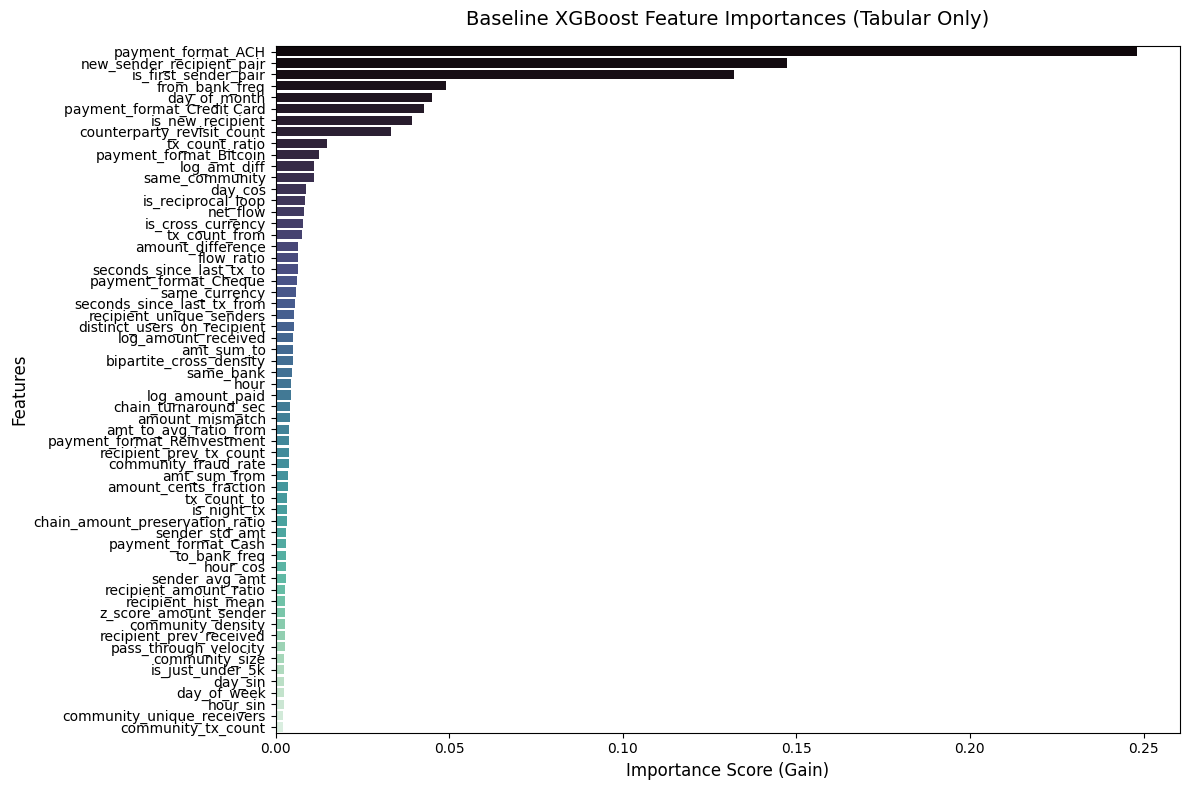

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract baseline feature importances (Tabular Only)
fi_baseline_df = pd.DataFrame({
    'Feature': X_train_p.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Print Top 15 Baseline Features
print("=" * 60)
print("BASELINE XGBOOST - TOP FEATURES (TABULAR ONLY)")
print("=" * 60)
print(fi_baseline_df.head(15).to_string(index=False))
print("=" * 60)

# Visual Bar Plot for Baseline
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=fi_baseline_df.head(60), 
    hue='Feature', 
    palette='mako', 
    legend=False
)
plt.title('Baseline XGBoost Feature Importances (Tabular Only)', fontsize=14, pad=15)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()